--2026-06-09 04:12:56--  https://bmild.github.io/nerf/tiny_nerf_data.npz
Resolving bmild.github.io (bmild.github.io)... 185.199.108.153, 185.199.110.153, 185.199.111.153, ...
Connecting to bmild.github.io (bmild.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12727482 (12M) [application/octet-stream]
Saving to: ‘tiny_nerf_data.npz’

tiny_nerf_data.npz  100%[===================>]  12.14M  --.-KB/s    in 0.1s    

2026-06-09 04:12:57 (83.0 MB/s) - ‘tiny_nerf_data.npz’ saved [12727482/12727482]


✅ --- ¡ÉXITO TOTAL! DATOS CARGADOS --- ✅
Imágenes: (106, 100, 100, 3), Poses: (106, 4, 4), Focal: 138.88887889922103


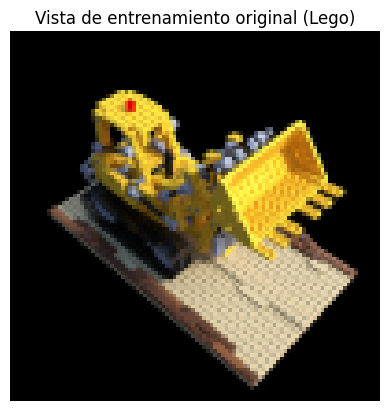

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Borramos cualquier archivo residual
!rm -f tiny_nerf_data.npz

# 2. Descargamos usando el host oficial del creador en GitHub Pages
# (Si este llegara a fallar por alguna razón, puedes cambiar el link por:
#  http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz )
!wget -O tiny_nerf_data.npz "https://bmild.github.io/nerf/tiny_nerf_data.npz"

# 3. Cargamos los datos
try:
    data = np.load('tiny_nerf_data.npz')
    images = data['images']
    poses = data['poses']
    focal = data['focal']

    print("\n --- ¡ÉXITO TOTAL! DATOS CARGADOS --- ")
    print(f"Imágenes: {images.shape}, Poses: {poses.shape}, Focal: {focal}")

    # Mostramos una de las imágenes de prueba
    plt.imshow(images[101])
    plt.title("Vista de entrenamiento original (Lego)")
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"\n Error al cargar el archivo. Detalles: {e}")
    print("Parece que las políticas de red de tu Colab están bloqueando las descargas.")

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Configurar GPU y convertir datos a tensores
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

images_t = torch.from_numpy(images).to(device)
poses_t = torch.from_numpy(poses).to(device)
focal_t = torch.tensor(focal).to(device)

# --- LÍNEA CORREGIDA AQUI ---
# Extraemos la altura y anchura de la forma de las imágenes
H, W = images.shape[1:3]
H, W = int(H), int(W)

# 2. Codificación Posicional (Ayuda a la red a ver detalles finos)
def posenc(x):
    rets = [x]
    for i in range(6): # 6 frecuencias
        for fn in [torch.sin, torch.cos]:
            rets.append(fn(2.**i * x))
    return torch.cat(rets, dim=-1)

# 3. La Red Neuronal (Tiny-NeRF MLP)
class TinyNeRF(nn.Module):
    def __init__(self, filter_size=128):
        super().__init__()
        self.layer1 = nn.Linear(39, filter_size) # 3D coord * (2*6+1) = 39
        self.layer2 = nn.Linear(filter_size, filter_size)
        self.layer3 = nn.Linear(filter_size, filter_size)
        self.layer4 = nn.Linear(filter_size, 4) # Salida: RGB (3) + Densidad (1)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        return self.layer4(x)

# 4. Función para calcular el origen y dirección de los rayos
def get_rays(H, W, focal, c2w):
    i, j = torch.meshgrid(torch.arange(W, dtype=torch.float32).to(device),
                          torch.arange(H, dtype=torch.float32).to(device), indexing='xy')
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], -1)
    rays_d = torch.sum(dirs[..., None, :] * c2w[:3, :3], -1)
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o, rays_d

model = TinyNeRF().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
print("Red Neuronal y motor de rayos inicializados correctamente.")

Entrenando en: cuda
Red Neuronal y motor de rayos inicializados correctamente.


In [7]:
import time

# Parámetros de renderizado
N_samples = 64
t_vals = torch.linspace(2., 6., steps=N_samples).to(device)

print("Iniciando entrenamiento...")
start_time = time.time()

for i in range(1001):
    # Seleccionar una imagen aleatoria para entrenar
    img_i = np.random.randint(images_t.shape[0])
    target = images_t[img_i]
    pose = poses_t[img_i]

    # 1. Lanzar rayos
    rays_o, rays_d = get_rays(H, W, focal_t, pose)

    # 2. Muestrear puntos 3D a lo largo del rayo
    z_vals = t_vals.unsqueeze(0).unsqueeze(0) + torch.rand((H, W, N_samples)).to(device) * ((6.-2.)/N_samples)
    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]

    # 3. Pasar puntos por la red
    pts_flat = pts.reshape(-1, 3)
    pts_enc = posenc(pts_flat)
    raw = model(pts_enc)
    raw = raw.reshape(H, W, N_samples, 4)

    # 4. Renderizar (Convertir densidad y color a un solo píxel 2D)
    sigma_a = F.relu(raw[..., 3])
    rgb = torch.sigmoid(raw[..., :3])

    dists = torch.cat([z_vals[..., 1:] - z_vals[..., :-1], torch.broadcast_to(torch.tensor([1e10]).to(device), z_vals[..., :1].shape)], -1)
    alpha = 1. - torch.exp(-sigma_a * dists)
    weights = alpha * torch.cumprod(torch.cat([torch.ones((alpha.shape[0], alpha.shape[1], 1)).to(device), 1. - alpha + 1e-10], -1), -1)[..., :-1]

    rgb_map = torch.sum(weights[..., None] * rgb, -2)

    # 5. Calcular error y optimizar
    loss = F.mse_loss(rgb_map, target)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    # Imprimir progreso cada 200 pasos
    if i % 200 == 0:
        psnr = -10. * torch.log10(loss)
        print(f"Paso {i:4d} | Pérdida: {loss.item():.4f} | PSNR: {psnr.item():.2f} dB")

tiempo_total = time.time() - start_time
print(f"🎉 Entrenamiento finalizado en {tiempo_total/60:.2f} minutos.")

Iniciando entrenamiento...
Paso    0 | Pérdida: 0.0866 | PSNR: 10.63 dB
Paso  200 | Pérdida: 0.0539 | PSNR: 12.69 dB
Paso  400 | Pérdida: 0.0116 | PSNR: 19.35 dB
Paso  600 | Pérdida: 0.0077 | PSNR: 21.11 dB
Paso  800 | Pérdida: 0.0103 | PSNR: 19.86 dB
Paso 1000 | Pérdida: 0.0111 | PSNR: 19.56 dB
🎉 Entrenamiento finalizado en 1.58 minutos.
